In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt

# 2.1 Exercise - 1

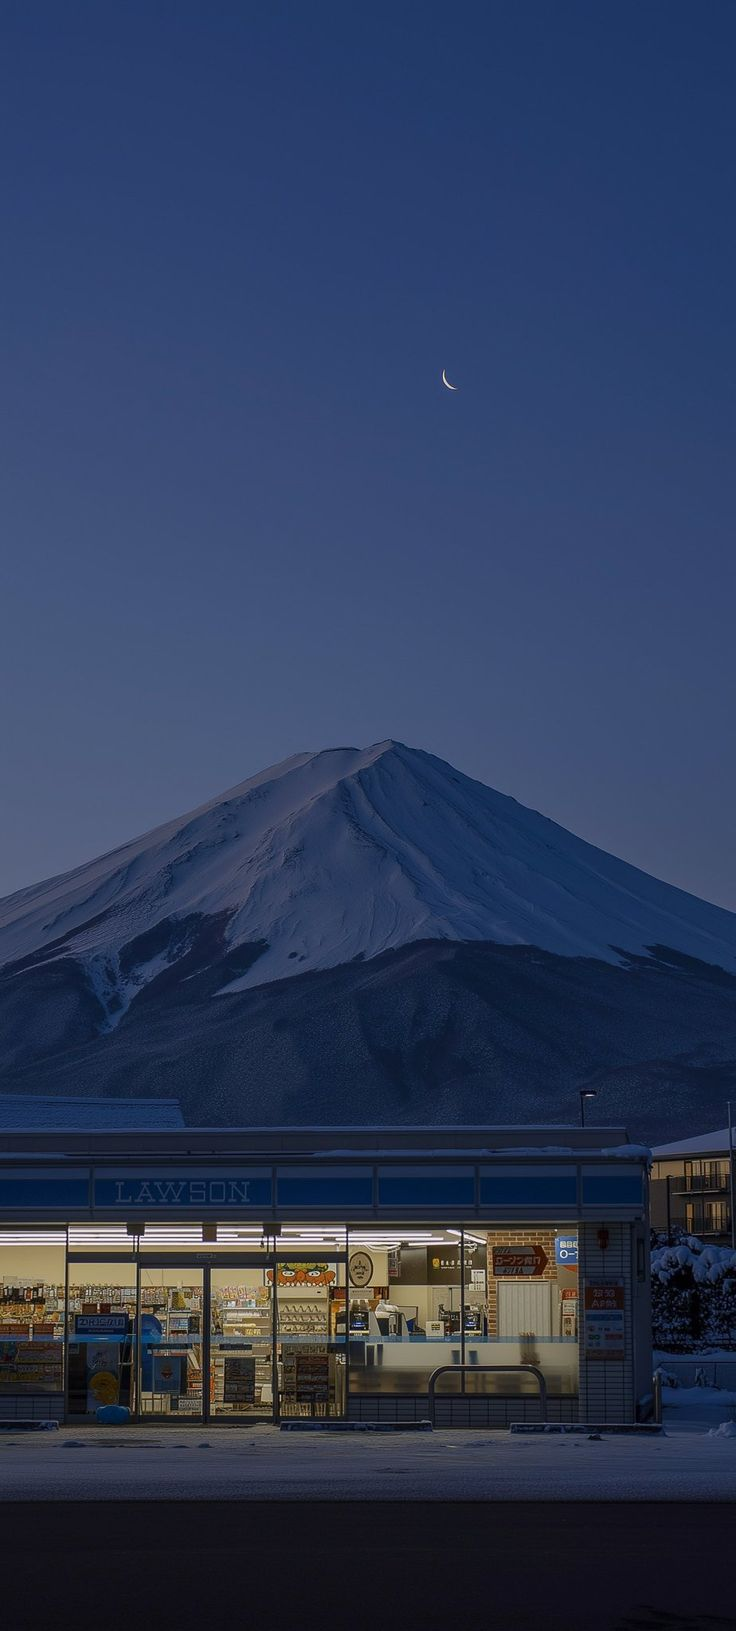

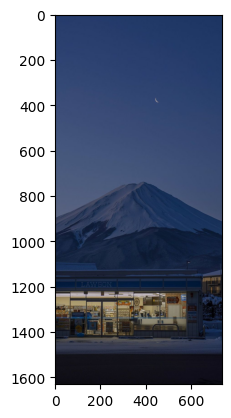

In [3]:
#task 1
image_path = '/content/drive/MyDrive/ai-workshop-1/image.jpg'
image = Image.open(image_path)

# show using display
display(image)

#show using plt
plt.imshow(image)
plt.show()

array([[[ 38,  60, 107],
        [ 38,  60, 107],
        [ 38,  60, 107],
        ...,
        [ 39,  60, 107],
        [ 39,  60, 107],
        [ 39,  60, 107]],

       [[ 38,  60, 107],
        [ 38,  60, 107],
        [ 38,  60, 107],
        ...,
        [ 39,  60, 107],
        [ 39,  60, 107],
        [ 39,  60, 107]],

       [[ 38,  60, 107],
        [ 38,  60, 107],
        [ 38,  60, 107],
        ...,
        [ 39,  60, 107],
        [ 39,  60, 107],
        [ 39,  60, 107]],

       ...,

       [[ 43,  64, 111],
        [ 43,  64, 111],
        [ 43,  64, 111],
        ...,
        [ 42,  63, 110],
        [ 42,  63, 110],
        [ 42,  63, 110]],

       [[ 43,  64, 111],
        [ 43,  64, 111],
        [ 43,  64, 111],
        ...,
        [ 42,  63, 110],
        [ 42,  63, 110],
        [ 42,  63, 110]],

       [[ 43,  64, 111],
        [ 43,  64, 111],
        [ 43,  64, 111],
        ...,
        [ 42,  63, 110],
        [ 42,  63, 110],
        [ 42,  63, 110]]], dtype=uint8)
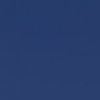

In [4]:
#task 2
img_array = np.array(image)

top_left = img_array[0:100, 0:100]

display(top_left)

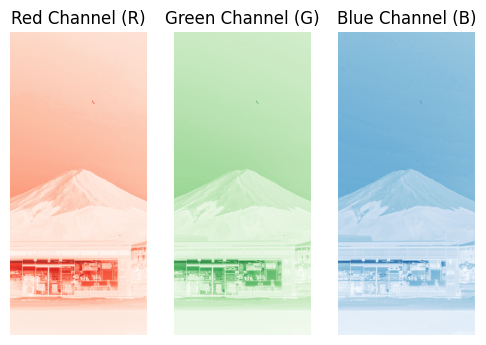

In [5]:
#task 3
R = img_array[:, :, 0]
G = img_array[:, :, 1]
B = img_array[:, :, 2]

plt.figure(figsize=(6,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap='Reds')
plt.title("Red Channel (R)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap='Greens')
plt.title("Green Channel (G)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap='Blues')
plt.title("Blue Channel (B)")
plt.axis("off")

plt.show()

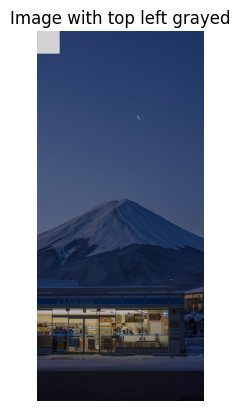

In [6]:
#task 4
modified_img = img_array.copy()

modified_img[0:100, 0:100] = 210

plt.imshow(modified_img)
plt.title("Image with top left grayed")
plt.axis("off")
plt.show()

# 2.2 Exercise - 2:

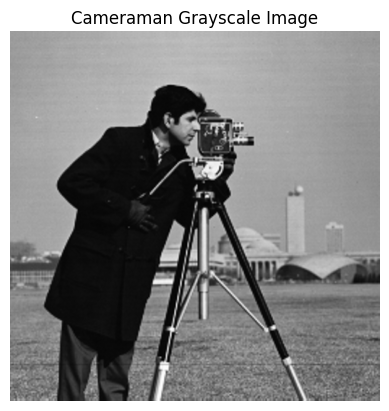

In [7]:
#task 1
image_path = '/content/drive/MyDrive/ai-workshop-1/cameraman.png'
image = Image.open(image_path)

img_array = np.array(image)

plt.imshow(img_array, cmap='gray')
plt.title("Cameraman Grayscale Image")
plt.axis("off")
plt.show()

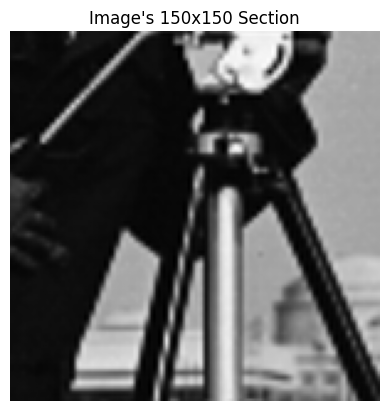

In [8]:
# task 2
img_array = np.array(image)

height, width = img_array.shape[:2]

center_y = height // 2
center_x = width // 2

half_size = 75
middle_section = img_array[
    center_y - half_size : center_y + half_size,
    center_x - half_size : center_x + half_size
]

plt.imshow(middle_section, cmap='gray')
plt.title("Image's 150x150 Section")
plt.axis("off")
plt.show()

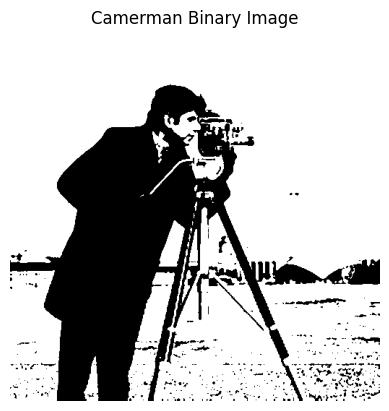

In [9]:
#task 3

binary_image = np.where(img_array < 100, 0, 255)

plt.imshow(binary_image, cmap='gray')
plt.title("Camerman Binary Image")
plt.axis("off")
plt.show()

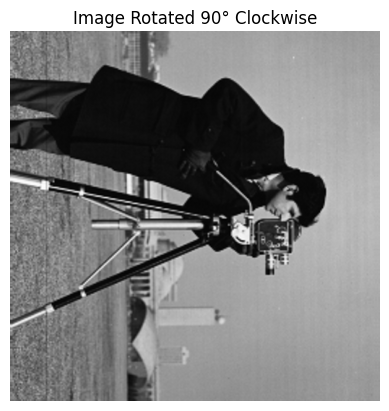

In [10]:
#task 4

rotated_image = image.rotate(-90)

plt.imshow(rotated_image, cmap='gray')
plt.title("Image Rotated 90° Clockwise")
plt.axis("off")
plt.show()

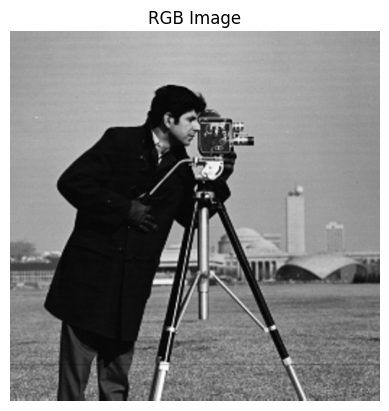

In [11]:
#task 5

gray_array = np.array(image)

rgb_array = np.stack((gray_array,)*3, axis=-1)

plt.imshow(rgb_array)
plt.title("RGB Image")
plt.axis("off")
plt.show()

# Image Compression and Decompression using PCA

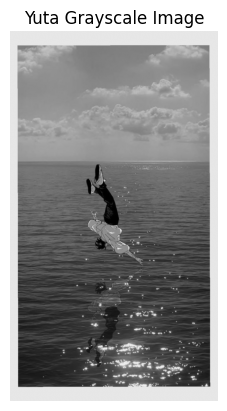

This is [[229. 229. 229. ... 229. 229. 229.]
 [229. 229. 229. ... 229. 229. 229.]
 [229. 229. 229. ... 229. 229. 229.]
 ...
 [229. 229. 229. ... 229. 229. 229.]
 [229. 229. 229. ... 229. 229. 229.]
 [229. 229. 229. ... 229. 229. 229.]]
Mean shape: (736,)
Centered data shape: (1308, 736)
Covariance matrix shape: (736, 736)
Covariance matrix:
 [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [12]:
image_path = '/content/drive/MyDrive/ai-workshop-1/free.jpg'
image = Image.open(image_path).convert("L")

img_array = np.array(image)
plt.imshow(img_array, cmap='gray')
plt.title("Yuta Grayscale Image")
plt.axis("off")
plt.show()

X = img_array.astype(float)
print("This is",X)

mean = np.mean(X, axis=0)

X_centered = X - mean
print("Mean shape:", mean.shape)
print("Centered data shape:", X_centered.shape)

cov_matrix = np.cov(X_centered, rowvar=False)
print("Covariance matrix shape:", cov_matrix.shape)
print("Covariance matrix:\n", cov_matrix)

In [13]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

sorted_indices = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

print("Eigenvalues shape:", eigenvalues.shape)
print("Eigenvectors shape:", eigenvectors.shape)

Eigenvalues shape: (736,)
Eigenvectors shape: (736, 736)


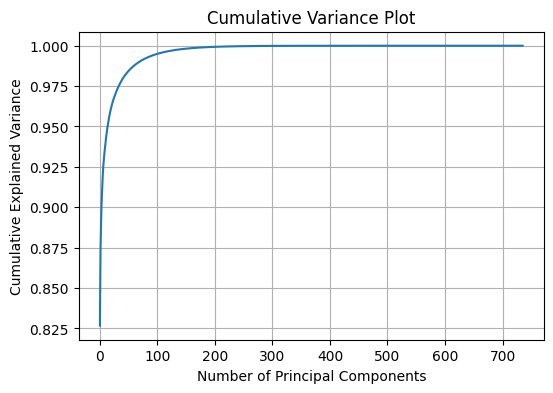

In [14]:
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)

cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(6,4))
plt.plot(cumulative_variance)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Variance Plot")
plt.grid()
plt.show()

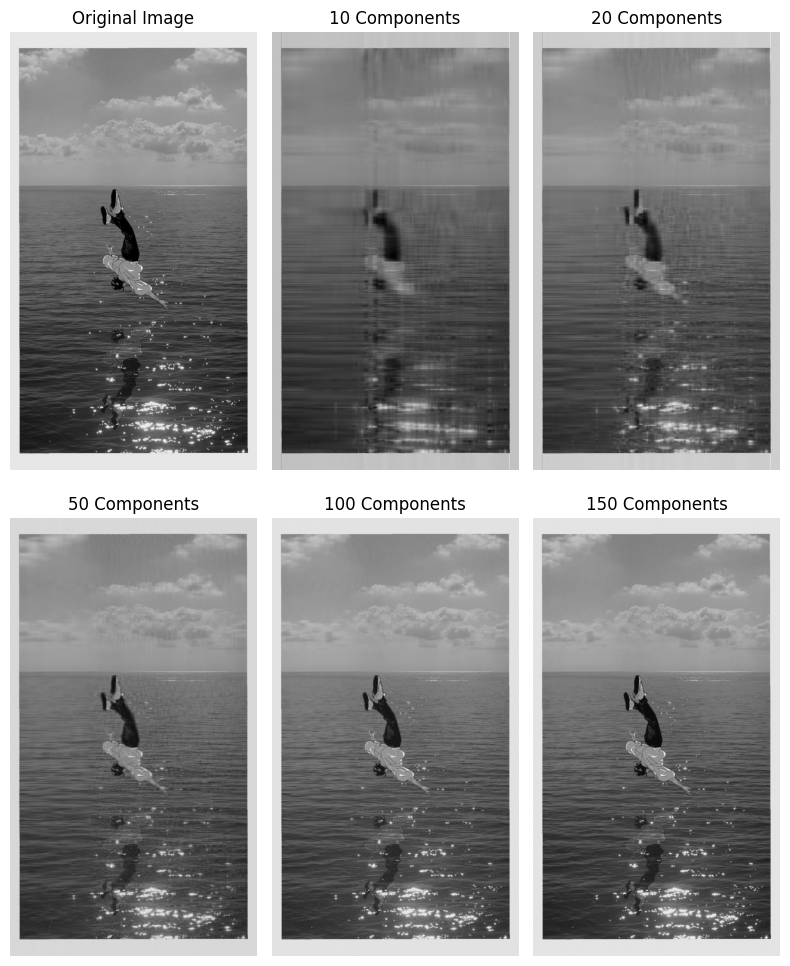

In [15]:
def reconstruct_image(X_centered, eigenvectors, k, mean):
    PCs = eigenvectors[:, :k]

    X_reduced = np.dot(X_centered, PCs)

    X_reconstructed = np.dot(X_reduced, PCs.T) + mean

    return X_reconstructed

k_values = [10, 20, 50, 100, 150]

plt.figure(figsize=(8, 10))

plt.subplot(2, 3, 1)
plt.imshow(img_array, cmap='gray')
plt.title("Original Image")
plt.axis("off")

for i, k in enumerate(k_values):
    reconstructed = reconstruct_image(X_centered, eigenvectors, k, mean)
    plt.subplot(2, 3, i+2)
    plt.imshow(reconstructed, cmap='gray')
    plt.title(f"{k} Components")
    plt.axis("off")

plt.tight_layout()
plt.show()

At 10-20 components the reconstructed image has many vertical slashes. At 50-100 components the reconstructed image has gotten significantly sharper and better. Though from 100 components onwards the result has not increased by a big margin.